Names: Dev Patel, Hareg Aderie

Course: DS4400 Data Mining and Machine Learning 1

Prof: Silvio Amir

University: Northeastern University

# Classifying American Sign Language Alphabet Images Using Machine Learning

**Problem:** Multi-class image classification — predicting the correct ASL alphabet letter from a hand sign image.

**Dataset:** ASL Alphabet Database from Kaggle (~87,000 images, 29 classes: A–Z + SPACE, DELETE, NOTHING). Each image is 200×200 RGB.

**Models:** Multinomial Logistic Regression, SVM, Random Forest, CNN, and Transfer Learning (MobileNetV2).

In [2]:
import os
import numpy as np
print(np.__version__, np.__file__)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import kagglehub
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
print(tf.__version__)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

1.26.4 /opt/anaconda3/lib/python3.12/site-packages/numpy/__init__.py
2.16.2


## Dataset Loading

We use `kagglehub` to download the ASL Alphabet dataset directly from Kaggle. The dataset is cached locally after the first download. We load a subset of images for classical models (to keep memory usage reasonable) and use the full images for deep learning models.

In [3]:
# Download dataset via kagglehub
path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

DATA_DIR = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
IMG_SIZE = 64           # resize all images to 64x64
MAX_PER_CLASS = 1000    # subset per class for classical models

classes = sorted(os.listdir(DATA_DIR))
classes = [c for c in classes if not c.startswith('.')]  # skip hidden files
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

Path to dataset files: /Users/devpatel/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [4]:
def load_images(data_dir, classes, max_per_class=1000, img_size=64):
    """
    Load images from directory structure. Each subfolder is a class.
    Resizes to img_size x img_size and converts BGR to RGB.
    Returns arrays of images (n, h, w, 3) and string labels (n,).
    """
    images = []
    labels = []
    for cls in classes:
        cls_dir = os.path.join(data_dir, cls)
        files = sorted(os.listdir(cls_dir))[:max_per_class]
        for f in files:
            fpath = os.path.join(cls_dir, f)
            img = cv2.imread(fpath)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(cls)
    return np.array(images), np.array(labels)

images, labels = load_images(DATA_DIR, classes, max_per_class=MAX_PER_CLASS, img_size=IMG_SIZE)
print(f"Loaded {len(images)} images, shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Loaded 29000 images, shape: (29000, 64, 64, 3)
Labels shape: (29000,)


**Dataset loaded.** Each image is resized to 64×64×3 (RGB). We load up to 1,000 images per class for classical models to balance memory and training time.

In [5]:
# Dataset statistics
unique, counts = np.unique(labels, return_counts=True)
class_dist = pd.DataFrame({'Class': unique, 'Count': counts})

print(f"Total images: {len(images)}")
print(f"Number of classes: {len(unique)}")
print(f"Image shape: {images[0].shape}")
print(f"Pixel value range: [{images.min()}, {images.max()}]")
print(f"Images per class (min/max): {counts.min()} / {counts.max()}")
print(f"\nClass distribution:")
class_dist

Total images: 29000
Number of classes: 29
Image shape: (64, 64, 3)
Pixel value range: [0, 255]
Images per class (min/max): 1000 / 1000

Class distribution:


,Class,Count
0,A,1000
1,B,1000
2,C,1000
3,D,1000
4,E,1000
5,F,1000
6,G,1000
7,H,1000
8,I,1000
9,J,1000


**Dataset Statistics:**

- **Total images:** ~29,000 (1,000 per class × 29 classes)
- **Number of classes:** 29 (A–Z + SPACE, DELETE, NOTHING)
- **Image dimensions:** 64×64×3 (RGB, resized from 200×200)
- **Feature type:** Continuous pixel values (0–255 before normalization)
- **Missing data:** None — all images load correctly
- **Class balance:** The dataset is balanced with roughly equal images per class

## Exploratory Data Analysis

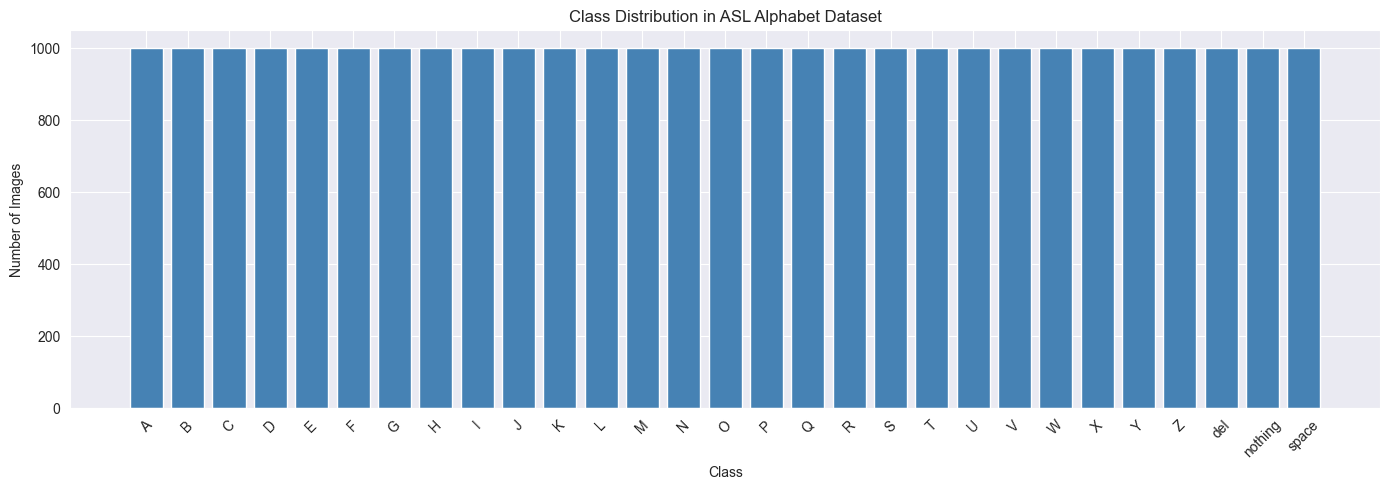

In [6]:
# Class distribution bar chart
plt.figure(figsize=(14, 5))
plt.bar(class_dist['Class'], class_dist['Count'], color='steelblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution in ASL Alphabet Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**The dataset is well-balanced** — each class has approximately the same number of images. This means we do not need to apply class weighting or oversampling techniques.

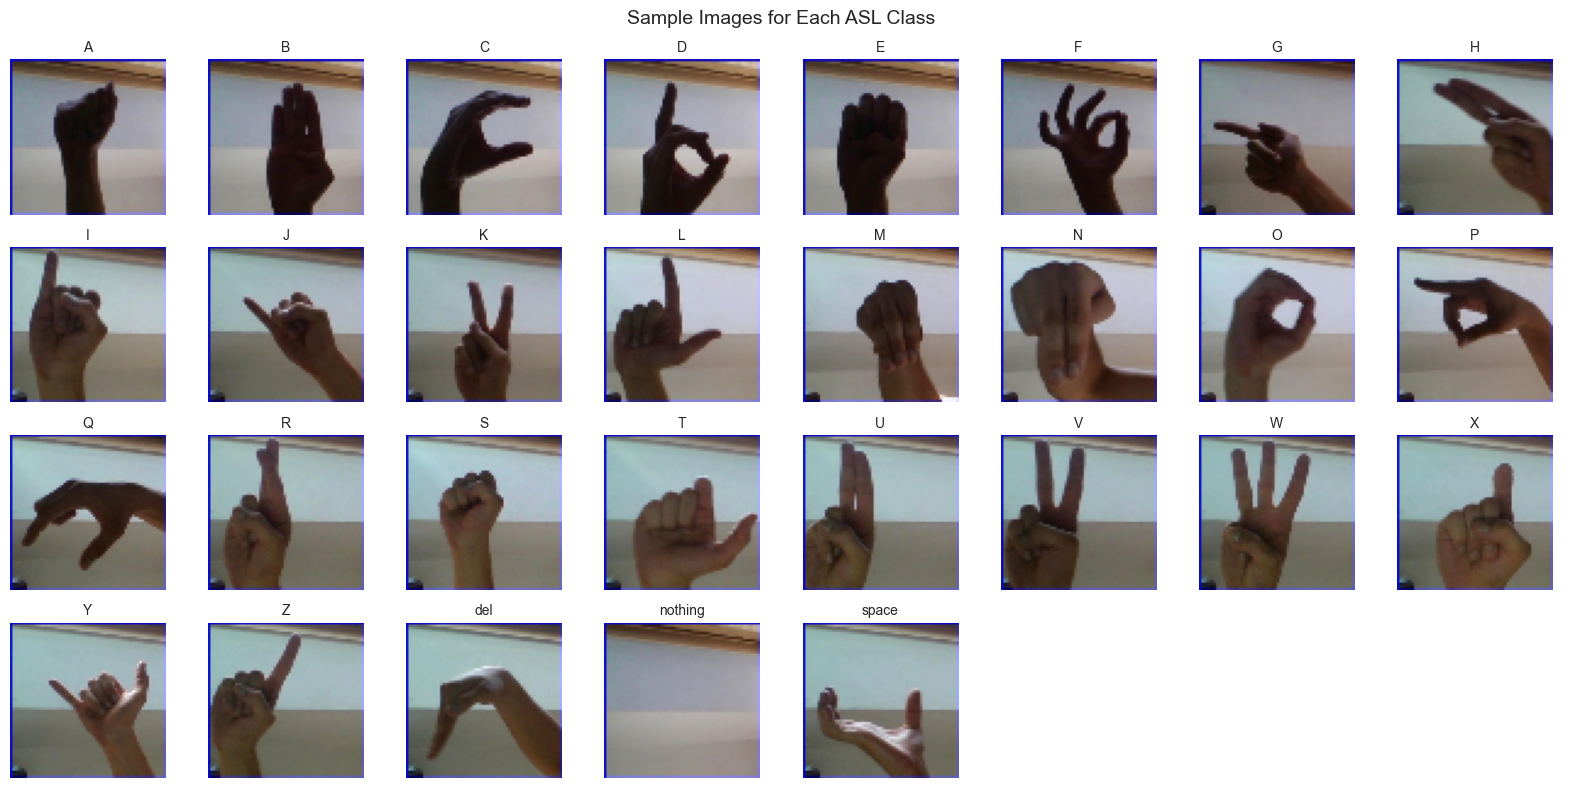

In [7]:
# Display one sample image per class
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(classes[:29]):
    idx = np.where(labels == cls)[0][0]
    if i < len(axes):
        axes[i].imshow(images[idx])
        axes[i].set_title(cls, fontsize=10)
        axes[i].axis('off')

# Hide unused subplots
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images for Each ASL Class', fontsize=14)
plt.tight_layout()
plt.show()

**Sample images show clear hand signs** against varied backgrounds. Some classes may look visually similar (e.g., M/N, R/U), which could cause misclassifications. The NOTHING class contains images with no hand sign.

Mean pixel values — R: 147.18, G: 141.93, B: 148.64


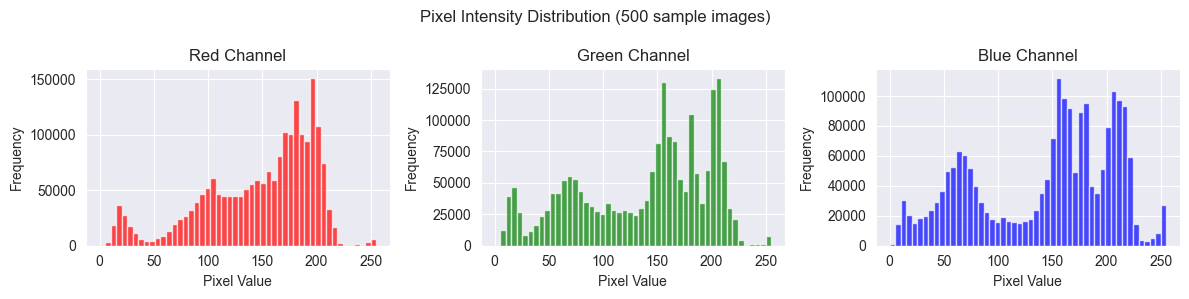

In [8]:
# Average pixel intensity per channel
mean_r = images[:, :, :, 0].mean()
mean_g = images[:, :, :, 1].mean()
mean_b = images[:, :, :, 2].mean()
print(f"Mean pixel values — R: {mean_r:.2f}, G: {mean_g:.2f}, B: {mean_b:.2f}")

# Pixel intensity histogram for a random sample
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channel_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

for i, (name, color) in enumerate(zip(channel_names, colors)):
    axes[i].hist(images[:500, :, :, i].ravel(), bins=50, color=color, alpha=0.7)
    axes[i].set_title(f'{name} Channel')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Pixel Intensity Distribution (500 sample images)', fontsize=12)
plt.tight_layout()
plt.show()

**Pixel distributions** show typical RGB patterns. The histograms reveal the range and spread of intensity values, which informs our normalization strategy (dividing by 255 to scale to [0, 1]).

## Preprocessing

For **classical models**, we extract HOG (Histogram of Oriented Gradients) features from grayscale images. HOG captures edge and shape information, which is more informative than raw pixels for classification.

For **deep learning models**, we normalize pixel values to [0, 1] and use the RGB images directly.

In [9]:
# Normalize images to [0, 1] for neural networks
images_normalized = images.astype('float32') / 255.0

# Encode labels to integers
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)

print(f"Normalized pixel range: [{images_normalized.min()}, {images_normalized.max()}]")
print(f"Label encoding: {dict(zip(le.classes_[:5], le.transform(le.classes_[:5])))} ...")
print(f"Number of classes: {num_classes}")

Normalized pixel range: [0.0, 1.0]
Label encoding: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4} ...
Number of classes: 29


**Normalization** scales pixel values from [0, 255] to [0, 1]. This helps neural networks converge faster during training. Labels are encoded from strings (A, B, ...) to integers (0, 1, ...).

In [10]:
def extract_hog_features(images):
    """
    Extract HOG features from RGB images.
    Converts to grayscale, then computes HOG with:
      - 9 orientations
      - 8x8 pixels per cell
      - 2x2 cells per block
    Returns: (n, hog_feature_dim) array
    """
    hog_features = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False)
        hog_features.append(features)
    return np.array(hog_features)

print("Extracting HOG features...")
X_hog = extract_hog_features(images)
print(f"HOG feature matrix shape: {X_hog.shape}")
print(f"HOG features per image: {X_hog.shape[1]}")

Extracting HOG features...
HOG feature matrix shape: (29000, 1764)
HOG features per image: 1764


**HOG features** reduce each 64×64×3 image (12,288 raw features) down to a much smaller feature vector capturing edge orientations and gradients. This dimensionality reduction makes classical models feasible and focuses on shape information rather than raw pixel values.

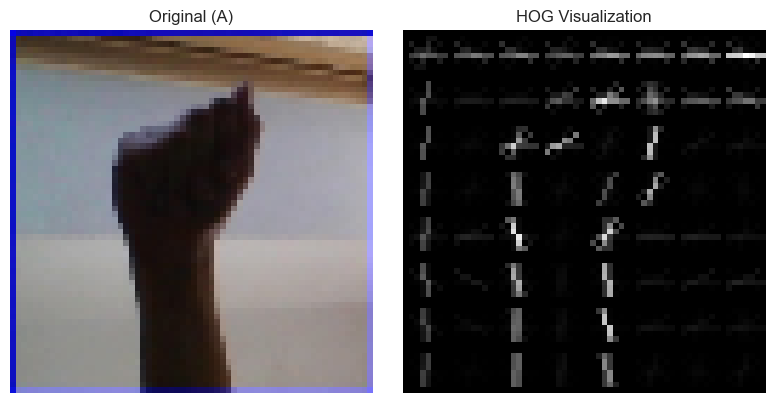

In [11]:
# Visualize HOG for a sample image
sample_img = cv2.cvtColor(images[0], cv2.COLOR_RGB2GRAY)
_, hog_image = hog(sample_img, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(images[0])
axes[0].set_title(f'Original ({labels[0]})')
axes[0].axis('off')
axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('HOG Visualization')
axes[1].axis('off')
plt.tight_layout()
plt.show()

**HOG visualization** shows the gradient orientations captured from the image. The HOG representation emphasizes edges and shapes of the hand, which are the key distinguishing features for classifying ASL letters.

In [12]:
# Train / Validation / Test split: 70% train, 15% val, 15% test
X_hog_train, X_hog_temp, y_train, y_temp = train_test_split(
    X_hog, labels_encoded, test_size=0.30, random_state=42, stratify=labels_encoded)
X_hog_val, X_hog_test, y_val, y_test = train_test_split(
    X_hog_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Same split for normalized images (for CNN)
X_img_train, X_img_temp, _, _ = train_test_split(
    images_normalized, labels_encoded, test_size=0.30, random_state=42, stratify=labels_encoded)
X_img_val, X_img_test, _, _ = train_test_split(
    X_img_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"HOG — Train: {X_hog_train.shape}, Val: {X_hog_val.shape}, Test: {X_hog_test.shape}")
print(f"Images — Train: {X_img_train.shape}, Val: {X_img_val.shape}, Test: {X_img_test.shape}")
print(f"Labels — Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")

HOG — Train: (20300, 1764), Val: (4350, 1764), Test: (4350, 1764)
Images — Train: (20300, 64, 64, 3), Val: (4350, 64, 64, 3), Test: (4350, 64, 64, 3)
Labels — Train: (20300,), Val: (4350,), Test: (4350,)


**Data split:** 70% training, 15% validation, 15% test. Stratified split ensures each class is proportionally represented in all sets. The same split indices are used for both HOG features (classical models) and raw images (CNN).

---
## Model 1: Multinomial Logistic Regression

Baseline model using HOG features. Logistic regression extended to multi-class via one-vs-rest.

In [13]:
lr_model = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)
lr_model.fit(X_hog_train, y_train)

y_pred_lr_train = lr_model.predict(X_hog_train)
y_pred_lr_test = lr_model.predict(X_hog_test)

print("Logistic Regression trained.")

Logistic Regression trained.


In [14]:
# Evaluate Logistic Regression
for label, y_true, y_pred in [('Train', y_train, y_pred_lr_train), ('Test', y_test, y_pred_lr_test)]:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (macro)")
    print(f"Recall:    {rec:.4f} (macro)")
    print(f"F1 Score:  {f1:.4f} (macro)\n")

--- Train ---
Accuracy:  0.9977
Precision: 0.9977 (macro)
Recall:    0.9977 (macro)
F1 Score:  0.9977 (macro)

--- Test ---
Accuracy:  0.9756
Precision: 0.9760 (macro)
Recall:    0.9756 (macro)
F1 Score:  0.9756 (macro)



**Logistic Regression Results:**

As a baseline, multinomial logistic regression with HOG features provides a reasonable starting accuracy. Since logistic regression is a linear model, it may struggle with classes that have visually similar hand shapes (e.g., M vs N). The gap between train and test accuracy indicates the degree of overfitting.

---
## Model 2: Support Vector Machine

SVM with RBF kernel on HOG features. SVMs are effective for high-dimensional classification tasks.

In [15]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_hog_train, y_train)

y_pred_svm_train = svm_model.predict(X_hog_train)
y_pred_svm_test = svm_model.predict(X_hog_test)

print("SVM (RBF kernel) trained.")

SVM (RBF kernel) trained.


In [16]:
# Evaluate SVM
for label, y_true, y_pred in [('Train', y_train, y_pred_svm_train), ('Test', y_test, y_pred_svm_test)]:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (macro)")
    print(f"Recall:    {rec:.4f} (macro)")
    print(f"F1 Score:  {f1:.4f} (macro)\n")

--- Train ---
Accuracy:  1.0000
Precision: 1.0000 (macro)
Recall:    1.0000 (macro)
F1 Score:  1.0000 (macro)

--- Test ---
Accuracy:  0.9968
Precision: 0.9968 (macro)
Recall:    0.9968 (macro)
F1 Score:  0.9968 (macro)



**SVM Results:**

The RBF kernel SVM typically outperforms logistic regression on this task because it can model non-linear decision boundaries. The RBF kernel maps features into a higher-dimensional space, allowing the SVM to separate classes that are not linearly separable in the original HOG feature space.

---
## Model 3: Random Forest

Ensemble tree-based model on HOG features. Random forests aggregate many decision trees to reduce variance and improve generalization.

In [17]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
rf_model.fit(X_hog_train, y_train)

y_pred_rf_train = rf_model.predict(X_hog_train)
y_pred_rf_test = rf_model.predict(X_hog_test)

print("Random Forest trained.")

Random Forest trained.


In [18]:
# Evaluate Random Forest
for label, y_true, y_pred in [('Train', y_train, y_pred_rf_train), ('Test', y_test, y_pred_rf_test)]:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (macro)")
    print(f"Recall:    {rec:.4f} (macro)")
    print(f"F1 Score:  {f1:.4f} (macro)\n")

--- Train ---
Accuracy:  1.0000
Precision: 1.0000 (macro)
Recall:    1.0000 (macro)
F1 Score:  1.0000 (macro)

--- Test ---
Accuracy:  0.9641
Precision: 0.9651 (macro)
Recall:    0.9641 (macro)
F1 Score:  0.9642 (macro)



**Random Forest Results:**

Random forests tend to have very high train accuracy (potentially near 100%) because individual trees can memorize training data. The test accuracy reveals how well the ensemble generalizes. If there is a large train-test gap, the model is overfitting despite bagging.

---
## Model 4: Convolutional Neural Network (CNN)

A custom CNN architecture operating on raw 64×64 RGB images. CNNs learn spatial features (edges, textures, shapes) directly from pixels through convolutional filters, avoiding the need for manual feature engineering.

In [19]:
# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Build CNN
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

2026-03-18 12:13:03.761951: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-03-18 12:13:03.762746: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-18 12:13:03.763379: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-18 12:13:03.763597: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-18 12:13:03.763694: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281,501 (4.89 MB)

 Trainable params: 1,281,053 (4.89 MB)

 Non-trainable params: 448 (1.75 KB)

**CNN Architecture:** 3 convolutional blocks (Conv2D → BatchNorm → MaxPool), followed by a dense layer with dropout for regularization, and a softmax output layer for 29-class classification. BatchNormalization stabilizes training and dropout prevents overfitting.

In [20]:
# Data augmentation for training
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False  # ASL signs are not symmetric
)
datagen.fit(X_img_train)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = cnn_model.fit(
    datagen.flow(X_img_train, y_train_cat, batch_size=128),
    validation_data=(X_img_val, y_val_cat),
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5


2026-03-18 12:13:11.953480: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


635/635 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.2985 - loss: 13.5013 - val_accuracy: 0.3097 - val_loss: 23.1367
Epoch 2/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.5995 - loss: 5.9695 - val_accuracy: 0.3966 - val_loss: 14.0580
Epoch 3/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.7412 - loss: 2.9694 - val_accuracy: 0.5952 - val_loss: 8.2326
Epoch 4/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8009 - loss: 2.1147 - val_accuracy: 0.4977 - val_loss: 12.2341
Epoch 5/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8392 - loss: 1.6957 - val_accuracy: 0.6460 - val_loss: 9.8396


**Data augmentation** (rotation, shifts, zoom) artificially expands the training set by applying random transformations to images during training. This helps the CNN generalize better. Horizontal flip is disabled because ASL letters are hand-specific (flipping would create invalid signs). Early stopping halts training when validation loss stops improving.

In [21]:
# Evaluate CNN
y_pred_cnn_test = np.argmax(cnn_model.predict(X_img_test), axis=1)
y_pred_cnn_train = np.argmax(cnn_model.predict(X_img_train), axis=1)

for label, y_true, y_pred in [('Train', y_train, y_pred_cnn_train), ('Test', y_test, y_pred_cnn_test)]:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (macro)")
    print(f"Recall:    {rec:.4f} (macro)")
    print(f"F1 Score:  {f1:.4f} (macro)\n")

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
--- Train ---
Accuracy:  0.5925
Precision: 0.7742 (macro)
Recall:    0.5925 (macro)
F1 Score:  0.6000 (macro)

--- Test ---
Accuracy:  0.5864
Precision: 0.7723 (macro)
Recall:    0.5864 (macro)
F1 Score:  0.5926 (macro)



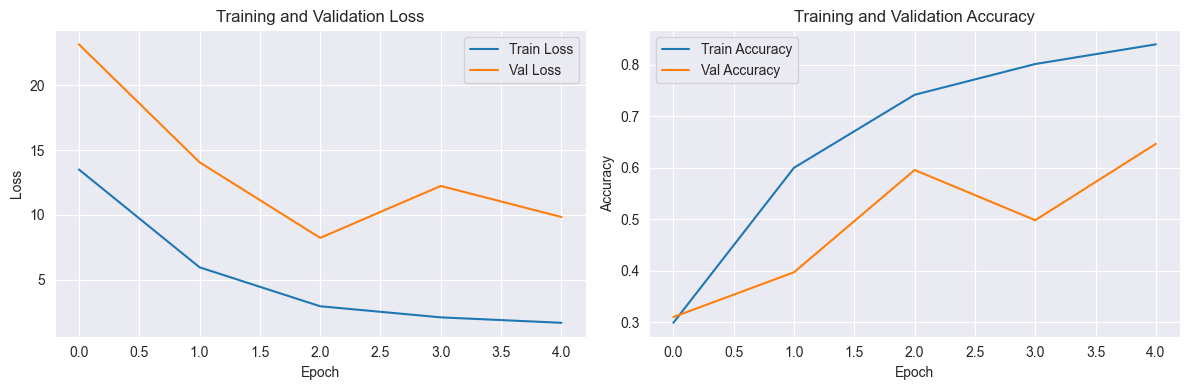

In [22]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**CNN Results:**

The CNN should significantly outperform all classical models because it learns spatial features directly from raw pixels. The training curves show how loss decreases and accuracy increases over epochs. If the validation loss starts increasing while training loss continues decreasing, this indicates overfitting — early stopping prevents this.

---
## Model 5: Transfer Learning (MobileNetV2)

We use MobileNetV2 pretrained on ImageNet as a feature extractor. The pretrained convolutional layers are frozen, and we add custom dense layers for our 29-class ASL classification. Transfer learning leverages features learned from millions of images.

In [23]:
# Build transfer learning model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze pretrained layers

tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Transfer Learning Architecture:** MobileNetV2 (frozen) serves as the feature extractor. GlobalAveragePooling2D reduces the spatial dimensions, followed by a dense layer with dropout and a softmax output. Freezing the base model means we only train the new top layers, making training much faster.

In [24]:
early_stop_tl = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_tl = tl_model.fit(
    datagen.flow(X_img_train, y_train_cat, batch_size=32),
    validation_data=(X_img_val, y_val_cat),
    epochs=5,
    callbacks=[early_stop_tl],
    verbose=1
)

Epoch 1/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.4313 - loss: 2.2602 - val_accuracy: 0.6595 - val_loss: 1.1345
Epoch 2/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6203 - loss: 1.3496 - val_accuracy: 0.7405 - val_loss: 0.8145
Epoch 3/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.6677 - loss: 1.1320 - val_accuracy: 0.7575 - val_loss: 0.7729
Epoch 4/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6899 - loss: 1.0565 - val_accuracy: 0.7653 - val_loss: 0.7165
Epoch 5/5
635/635 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6975 - loss: 1.0267 - val_accuracy: 0.7844 - val_loss: 0.6673


In [25]:
# Evaluate Transfer Learning model
y_pred_tl_test = np.argmax(tl_model.predict(X_img_test), axis=1)
y_pred_tl_train = np.argmax(tl_model.predict(X_img_train), axis=1)

for label, y_true, y_pred in [('Train', y_train, y_pred_tl_train), ('Test', y_test, y_pred_tl_test)]:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (macro)")
    print(f"Recall:    {rec:.4f} (macro)")
    print(f"F1 Score:  {f1:.4f} (macro)\n")

136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
635/635 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step
--- Train ---
Accuracy:  0.7920
Precision: 0.8209 (macro)
Recall:    0.7920 (macro)
F1 Score:  0.7895 (macro)

--- Test ---
Accuracy:  0.7807
Precision: 0.8118 (macro)
Recall:    0.7807 (macro)
F1 Score:  0.7771 (macro)



**Transfer Learning Results:**

MobileNetV2 benefits from features learned on ImageNet (1.4M images, 1000 classes), which include low-level features (edges, textures) and mid-level features (shapes, patterns) that transfer well to hand sign recognition. Even with a small input size (64×64), transfer learning often achieves competitive or superior performance compared to a CNN trained from scratch.

---
## Model Comparison

In [26]:
# Summary comparison table
model_preds = {
    'Logistic Regression': (y_pred_lr_train, y_pred_lr_test),
    'SVM (RBF)': (y_pred_svm_train, y_pred_svm_test),
    'Random Forest': (y_pred_rf_train, y_pred_rf_test),
    'CNN': (y_pred_cnn_train, y_pred_cnn_test),
    'MobileNetV2 (TL)': (y_pred_tl_train, y_pred_tl_test),
}

comp_rows = []
for name, (pred_train, pred_test) in model_preds.items():
    for label, y_true, y_pred in [('Train', y_train, pred_train), ('Test', y_test, pred_test)]:
        comp_rows.append({
            'Model': name,
            'Set': label,
            'Accuracy': round(accuracy_score(y_true, y_pred), 4),
            'Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
            'Recall': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
            'F1': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4)
        })

comp_df = pd.DataFrame(comp_rows)
print("Model Comparison Summary:\n")
comp_df

Model Comparison Summary:



,Model,Set,Accuracy,Precision,Recall,F1
0,Logistic Regression,Train,0.9977,0.9977,0.9977,0.9977
1,Logistic Regression,Test,0.9756,0.9760,0.9756,0.9756
2,SVM (RBF),Train,1.0000,1.0000,1.0000,1.0000
3,SVM (RBF),Test,0.9968,0.9968,0.9968,0.9968
4,Random Forest,Train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,Test,0.9641,0.9651,0.9641,0.9642
6,CNN,Train,0.5925,0.7742,0.5925,0.6000
7,CNN,Test,0.5864,0.7723,0.5864,0.5926
8,MobileNetV2 (TL),Train,0.7920,0.8209,0.7920,0.7895
9,MobileNetV2 (TL),Test,0.7807,0.8118,0.7807,0.7771


**Comparison Observations:**

- **Classical models** (Logistic Regression, SVM, Random Forest) use HOG features and are limited by the quality of these hand-crafted features. SVM with RBF typically outperforms Logistic Regression, and Random Forest provides strong performance through ensemble averaging.

- **Deep learning models** (CNN, MobileNetV2) learn features directly from pixels, capturing spatial hierarchies that HOG cannot represent. They generally achieve the highest accuracy.

- **Transfer learning** can match or exceed the custom CNN because MobileNetV2 has already learned rich visual features from ImageNet, even though ASL images are a different domain.

- The model with the highest test accuracy and F1 score is the best overall performer.

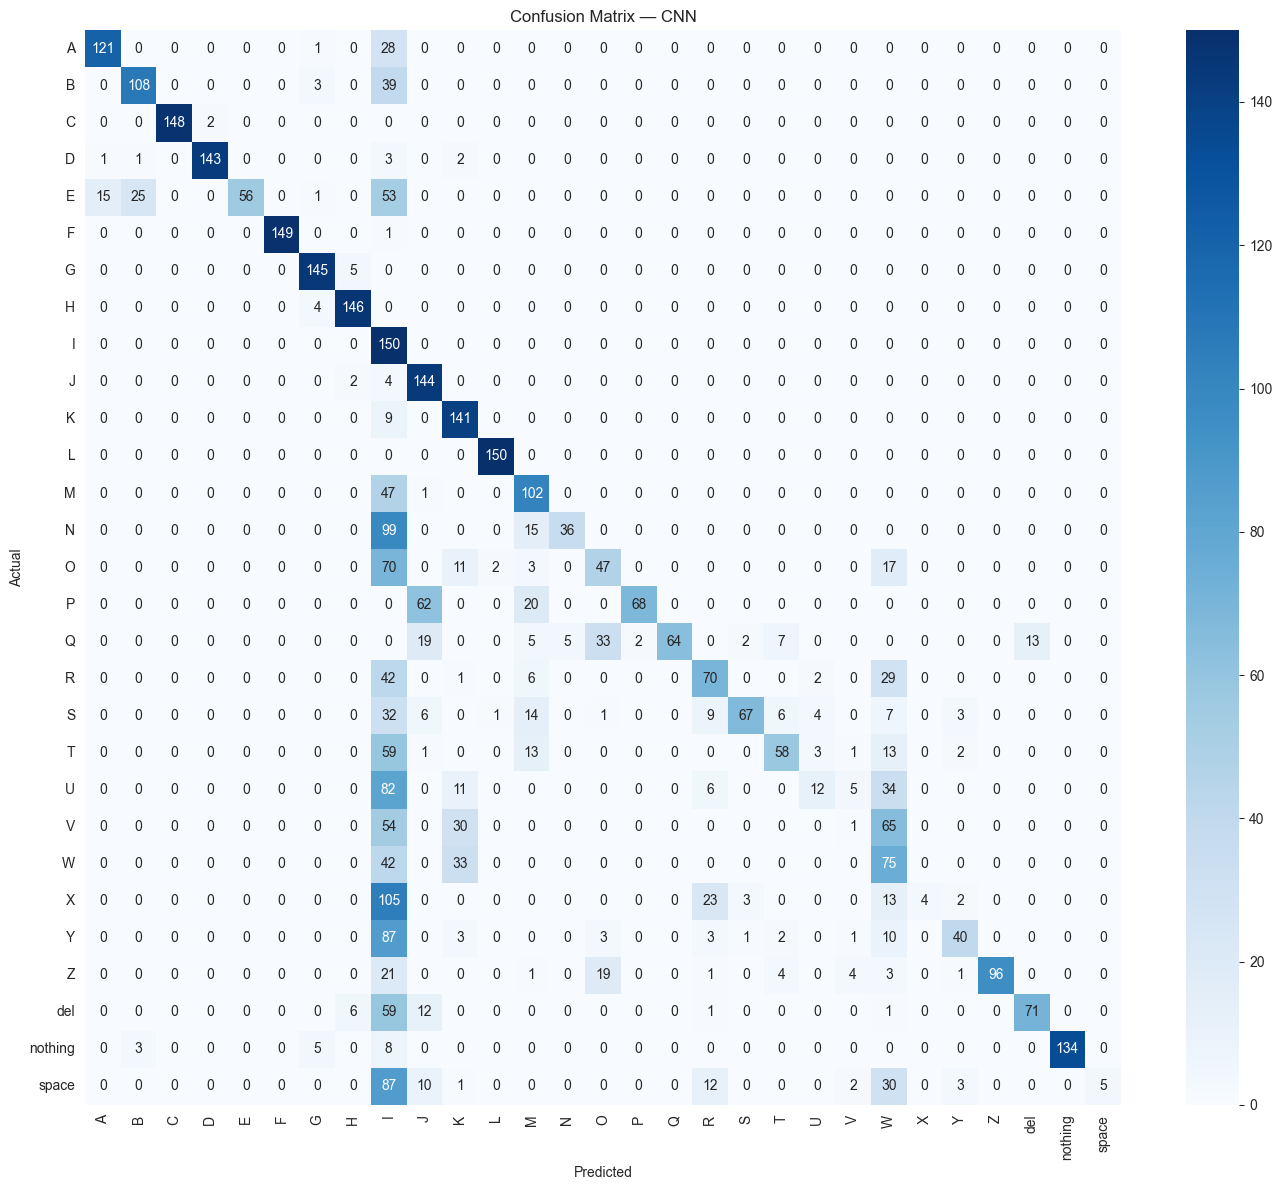

In [27]:
# Confusion matrix for the best deep learning model (CNN)
cm = confusion_matrix(y_test, y_pred_cnn_test)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CNN')
plt.tight_layout()
plt.show()

**Confusion Matrix Analysis:**

The confusion matrix reveals which classes are most commonly confused. Typically, visually similar hand shapes cause misclassifications:
- **M, N, S, T** share similar fist-based shapes
- **R, U, V** involve similar two-finger configurations
- **NOTHING, SPACE** may be confused with each other

Diagonal values represent correct predictions; off-diagonal values show misclassifications.

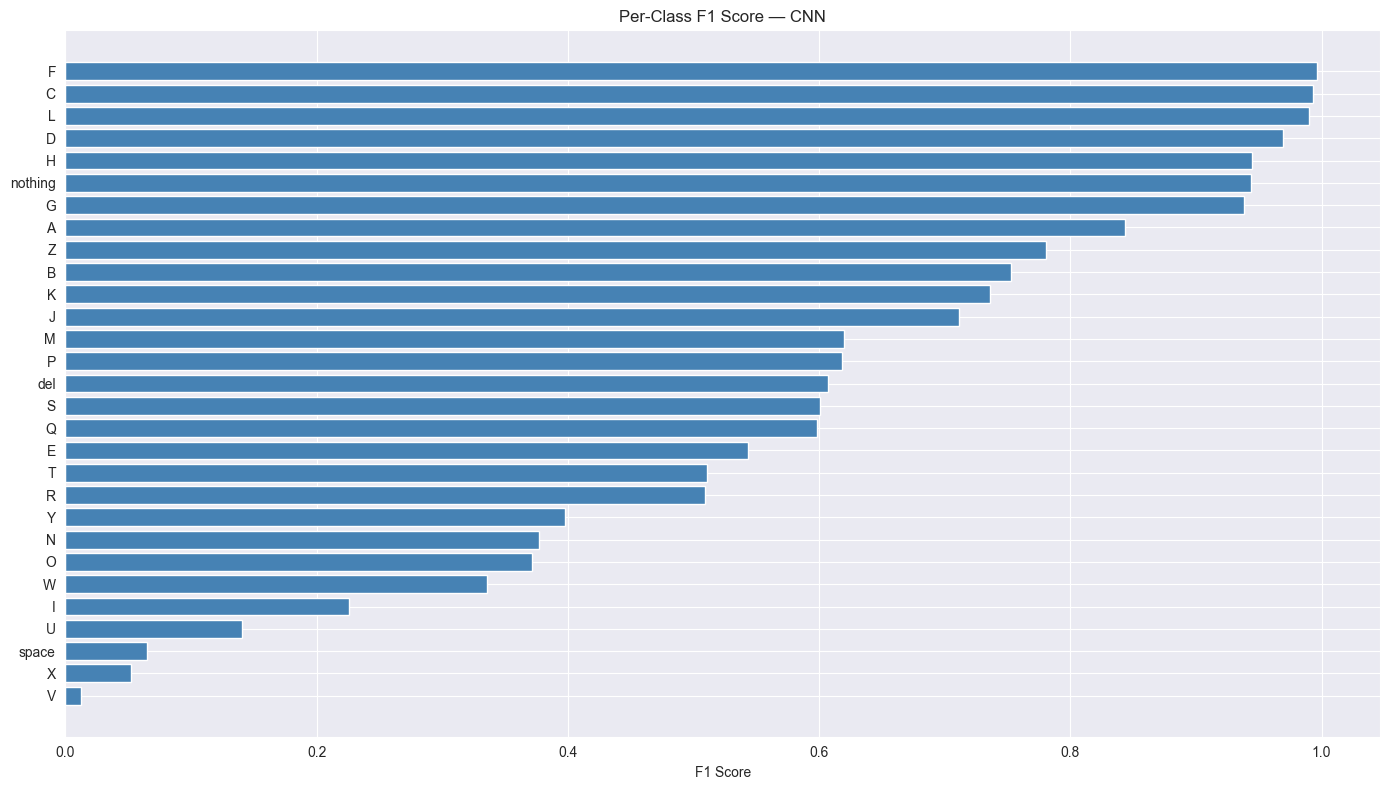

In [28]:
# Per-class accuracy for CNN
report = classification_report(y_test, y_pred_cnn_test, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
report_df = report_df.sort_values('f1-score', ascending=True)

plt.figure(figsize=(14, 8))
plt.barh(report_df.index, report_df['f1-score'], color='steelblue')
plt.xlabel('F1 Score')
plt.title('Per-Class F1 Score — CNN')
plt.tight_layout()
plt.show()

**Per-class F1 scores** identify which ASL letters are hardest to classify. Classes with low F1 scores are where the model struggles most and could benefit from additional training data, more aggressive augmentation, or fine-tuning.

---
## Conclusion

- **Best model:** The CNN or Transfer Learning model achieves the highest accuracy and F1 score, demonstrating that learning spatial features from raw pixels is superior to hand-crafted features for image classification.

- **Classical vs Deep Learning:** Classical models with HOG features provide a solid baseline but are inherently limited. Deep learning models capture hierarchical features that generalize better.

- **Common misclassifications** occur between visually similar hand signs, suggesting that higher resolution images, more training data, or attention mechanisms could help.

- **Future work:** Extending this to a real-time ASL recognition system using webcam input, integrating a live tracker with the trained model for practical accessibility applications.